# **09 LangGraph 조건부 엣지 - 의도 분류 기반 라우팅**

### 학습 내용
1. with_structured_output으로 구조화된 출력 생성
2. LLM 기반 의도 분류 구현
3. 조건부 엣지(Conditional Edge)로 라우팅
4. 의도별 응답 처리 시스템 구현

## 0. 환경 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 1. with_structured_output 이해하기

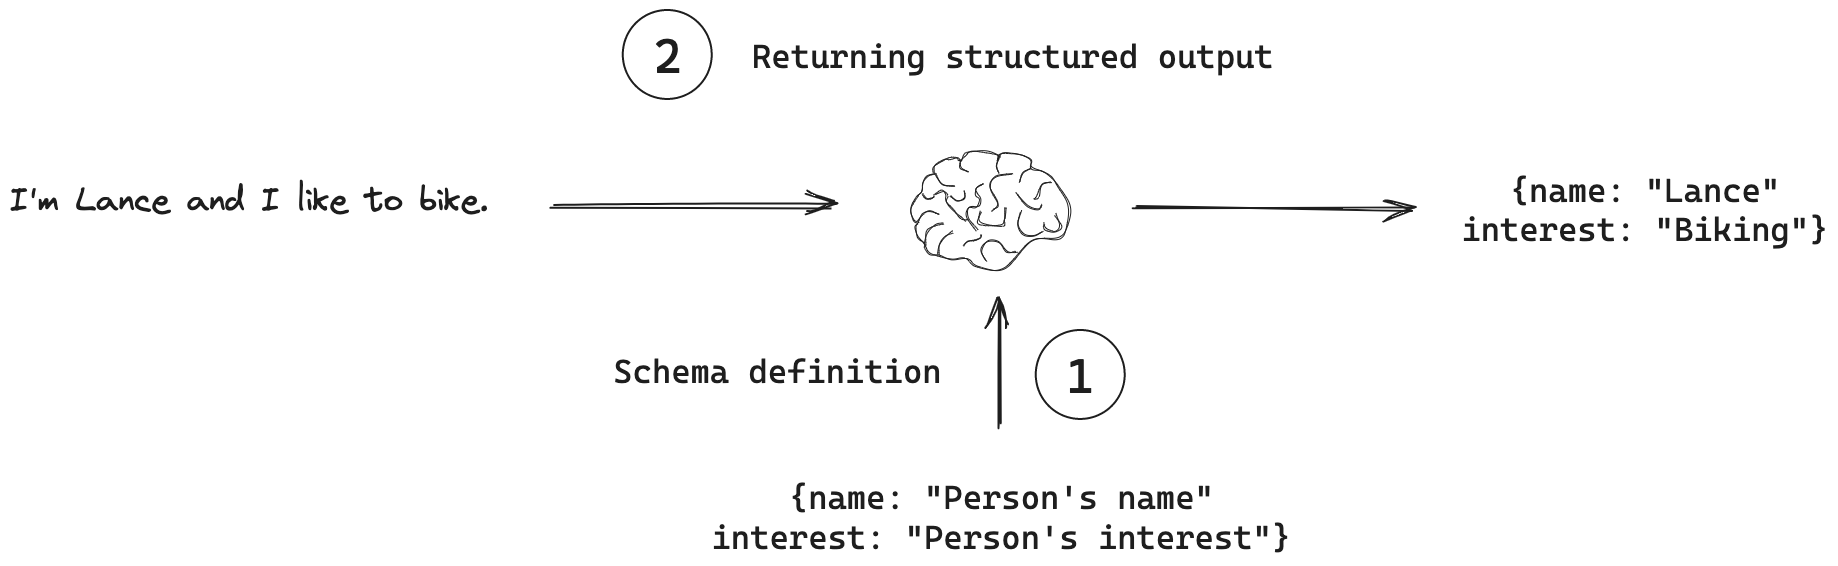

`with_structured_output`은 LLM의 출력을 **Pydantic 모델** (데이터 스키마)로 변환하는 기능입니다.

### 장점

- 자유 형식 텍스트 대신 **구조화된 데이터** 반환
- 타입 검증 및 파싱 자동화
- 조건 분기, 데이터 처리에 활용

### 사용 예시

일반 LLM 호출:
```python
response = llm.invoke("사용자 나이: 25")
# response.content = "사용자는 25세입니다."  # 문자열
```

구조화된 출력:
```python
response = llm.with_structured_output(User).invoke("사용자 나이: 25")
# response = User(age=25)  # Pydantic 객체
```

### 2-1. with_structured_output 기본 사용법

In [2]:
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field

# Pydantic 모델 정의
class Person(BaseModel):
    name: str = Field(description="사람의 이름")
    age: int = Field(description="사람의 나이")
    city: str = Field(description="사는 도시")

# LLM 초기화
llm = init_chat_model("gpt-5.4-mini")

# with_structured_output 적용
structured_llm = llm.with_structured_output(Person)

# 실행
text = "제 이름은 김철수이고, 30살이며 서울에 살고 있습니다."
result = structured_llm.invoke(text)

print(f"타입: {type(result)}")
print(f"결과: {result}")
print(f"이름: {result.name}")
print(f"나이: {result.age}")
print(f"도시: {result.city}")

타입: <class '__main__.Person'>
결과: name='김철수' age=30 city='서울'
이름: 김철수
나이: 30
도시: 서울


### 2-2. Enum을 사용한 분류 작업

In [3]:
from enum import Enum
from pydantic import BaseModel, Field

# 카테고리 정의
class Category(str, Enum):
    GREETING = "greeting"
    QUESTION = "question"
    COMPLAINT = "complaint"
    REQUEST = "request"

# 분류 결과 모델
class Classification(BaseModel):
    category: Category = Field(description="사용자 입력의 카테고리")
    confidence: float = Field(description="분류 확신도 (0.0 ~ 1.0)", ge=0.0, le=1.0)

# LLM에 적용
structured_llm = llm.with_structured_output(Classification)

# 테스트
test_texts = [
    "안녕하세요!",
    "이 제품은 어떻게 사용하나요?",
    "배송이 너무 늦어요. 불만입니다.",
    "환불 처리 부탁드립니다."
]

for text in test_texts:
    result = structured_llm.invoke(text)
    print(f"입력: {text}")
    print(f"카테고리: {result.category.value}")
    print(f"확신도: {result.confidence}")
    print("-" * 50)

입력: 안녕하세요!
카테고리: greeting
확신도: 0.99
--------------------------------------------------
입력: 이 제품은 어떻게 사용하나요?
카테고리: question
확신도: 0.98
--------------------------------------------------
입력: 배송이 너무 늦어요. 불만입니다.
카테고리: complaint
확신도: 0.99
--------------------------------------------------
입력: 환불 처리 부탁드립니다.
카테고리: request
확신도: 0.99
--------------------------------------------------


## 2. 의도 분류 기반 조건부 라우팅 시스템

사용자의 입력을 분석하여 의도를 분류하고, 의도에 따라 다른 노드로 라우팅하는 시스템을 구현합니다.

**시스템 구조**:
1. `analyze_intent` 노드: 사용자 입력 의도 분류 (with_structured_output 사용)
2. `route_by_intent` 함수: 의도에 따라 다음 노드 결정
3. 의도별 응답 노드: `respond_question`, `respond_complaint`, `respond_request`

이 패턴은 다음 단계에서 **문서 검색 vs DB 조회**를 선택하는 데이터 조회 시스템의 기초가 됩니다.

In [4]:
from typing import Literal
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from enum import Enum

# 의도 카테고리 정의
class Intent(str, Enum):
    QUESTION = "question"  # 일반 질문
    COMPLAINT = "complaint"  # 불만/클레임
    REQUEST = "request"  # 특정 작업 요청

# 의도 분류 결과 모델
class IntentClassification(BaseModel):
    intent: Intent = Field(description="사용자 입력의 의도")
    reason: str = Field(description="분류 이유")

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    intent: str  # 분류된 의도

# LLM 초기화
llm = init_chat_model("gpt-5.4-mini")

In [5]:
# 의도 분석 노드
def analyze_intent(state: State):
    print("의도 분석 중...")

    # 마지막 사용자 메시지 가져오기
    user_input = state["messages"][-1].content

    # with_structured_output으로 의도 분류
    structured_llm = llm.with_structured_output(IntentClassification)

    classification_prompt = f"""다음 사용자 입력의 의도를 분류하세요:

- question: 일반 질문, 정보 요청, 사용 방법 문의
- complaint: 불만, 클레임, 부정적 피드백
- request: 특정 작업 요청 (환불, 교환, 처리 등)

사용자 입력: {user_input}"""

    result = structured_llm.invoke(classification_prompt)

    print(f"의도: {result.intent.value}")
    print(f"이유: {result.reason}")

    return {"intent": result.intent.value}

# 의도에 따라 경로 결정하는 라우팅 함수
def route_by_intent(state: State) -> Literal["question", "complaint", "request"]:
    """의도에 따라 다음 노드를 결정"""
    intent = state["intent"]
    print(f"라우팅: {intent}")
    return intent

In [6]:
# 질문 응답 노드
def respond_question(state: State):
    print("질문 응답 생성 중...")

    user_input = state["messages"][-1].content

    messages = [
        SystemMessage(content="""당신은 고객의 문의 내용을 처리하는 챗봇입니다.
사용자로부터 일반 질문 혹은 정보 요청이 들어왔습니다.
명확하고 친절하게 답변하세요."""),
        HumanMessage(content=user_input)
    ]

    response = llm.invoke(messages)
    return {"messages": [response]}

# 불만 응답 노드
def respond_complaint(state: State):
    print("불만 응답 생성 중...")

    user_input = state["messages"][-1].content

    messages = [
        SystemMessage(content="""당신은 고객의 문의 내용을 처리하는 챗봇입니다.
사용자로부터 클레임이 들어왔습니다.
불만을 경청하고, 진심으로 사과하며, 구체적인 해결 방안을 제시하세요."""),
        HumanMessage(content=user_input)
    ]

    response = llm.invoke(messages)
    return {"messages": [response]}

# 요청 응답 노드
def respond_request(state: State):
    print("요청 응답 생성 중...")

    user_input = state["messages"][-1].content

    messages = [
        SystemMessage(content="""당신은 고객의 문의 내용을 처리하는 챗봇입니다.
사용자로부터 특정 작업 요청이 들어왔습니다.
요청을 확인하고, 처리 방법과 다음 단계를 안내해주세요."""),
        HumanMessage(content=user_input)
    ]

    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:
# 그래프 구성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("analyze_intent", analyze_intent)
graph_builder.add_node("question", respond_question)
graph_builder.add_node("complaint", respond_complaint)
graph_builder.add_node("request", respond_request)

# 엣지 연결
graph_builder.add_edge(START, "analyze_intent")

# 조건부 엣지 - 의도에 따라 라우팅
graph_builder.add_conditional_edges(
    "analyze_intent",  # 출발 노드
    route_by_intent,   # 라우팅 함수
    {
        "question": "question",      # 라우팅 함수 반환값: 도착 노드
        "complaint": "complaint",
        "request": "request",
    }
)

# 모든 응답 노드를 END로 연결
graph_builder.add_edge("question", END)
graph_builder.add_edge("complaint", END)
graph_builder.add_edge("request", END)

# 그래프 컴파일
graph = graph_builder.compile()

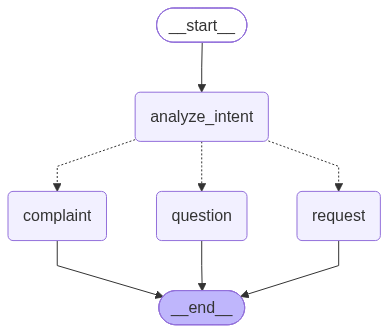

In [8]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 3. 실행 및 테스트

In [9]:
# 다양한 의도의 입력으로 테스트
test_inputs = [
    "이 제품은 어떻게 사용하나요?",
    "배송이 너무 늦어요. 정말 화가 나네요.",
    "환불 처리 부탁드립니다."
]

for user_input in test_inputs:
    print("\n" + "="*70)
    print(f"사용자 입력: {user_input}")
    print("="*70)

    result = graph.invoke({
        "messages": [HumanMessage(content=user_input)],
        "intent": ""
    })

    print(f"\n분류된 의도: {result['intent']}")
    print("\n응답:")
    print(result['messages'][-1].content)


사용자 입력: 이 제품은 어떻게 사용하나요?
의도 분석 중...
의도: question
이유: 제품의 사용 방법을 묻는 정보 요청이므로 질문에 해당합니다.
라우팅: question
질문 응답 생성 중...

분류된 의도: question

응답:
어떤 제품인지에 따라 사용 방법이 달라요.  
제품명이나 사진, 설명을 보내주시면 **사용 방법을 단계별로** 알려드릴게요.

예를 들어 아래 중 하나를 보내주세요:
- 제품명
- 사용 설명서 사진
- 제품 사진
- 어떤 용도인지 간단한 설명

원하시면 제가 바로 “처음 사용 방법 / 주의사항 / 보관 방법”까지 같이 정리해드릴게요.

사용자 입력: 배송이 너무 늦어요. 정말 화가 나네요.
의도 분석 중...
의도: complaint
이유: 배송 지연에 대한 불만과 강한 부정적 감정(화가 남)을 표현하고 있어 클레임으로 분류됩니다.
라우팅: complaint
불만 응답 생성 중...

분류된 의도: complaint

응답:
불편을 드려 정말 죄송합니다. 배송이 늦어 많이 답답하고 화가 나실 만합니다.

지금 바로 확인해드릴게요.  
가능하시면 아래 정보 중 하나를 보내주세요:
- 주문번호
- 수령인 이름
- 연락처 뒤 4자리

확인 후 바로
1) 현재 배송 상태를 조회하고  
2) 지연 사유를 안내드리며  
3) 가능한 경우 빠른 재배송 또는 환불/보상 절차까지 안내드리겠습니다.

기다리시게 해서 다시 한번 죄송합니다. 가능한 한 빠르게 도와드리겠습니다.

사용자 입력: 환불 처리 부탁드립니다.
의도 분석 중...
의도: request
이유: 환불 처리를 부탁하는 특정 작업 요청이므로 request에 해당합니다.
라우팅: request
요청 응답 생성 중...

분류된 의도: request

응답:
환불 처리를 도와드리겠습니다.

진행을 위해 아래 정보가 필요합니다:
1. 주문 번호
2. 환불 사유
3. 결제 수단
4. 환불받을 계좌 정보(계좌이체/무통장입금 결제인 경우)

정보를 보내주시면 확인 후 다음 단계 안

## 📖 과제 1: 이메일 & 캘린더 관리 의도 추가하기

위 섹션 2에서 구현한 의도 분류 시스템을 활용하여 **이메일 및 캘린더 관리 시스템**을 만들어봅시다.

### 과제 목표
사용자 입력을 분석하여 다음 4가지 의도로 분류하고, 각 의도에 맞는 작업을 수행하세요:
- **메일함 확인** (CHECK_MAIL): "메일함 보여줘", "받은 메일 확인"
- **메일 발송** (SEND_MAIL): "메일 보내줘", "이메일 전송"
- **캘린더 확인** (CHECK_CALENDAR): "오늘 일정 뭐야?", "캘린더 보여줘"
- **일정 추가** (ADD_SCHEDULE): "회의 일정 잡아줘", "스케줄 추가"

### 구현 단계
1. `Intent` Enum에 4가지 의도 정의
2. `route_by_intent` 함수의 반환 타입 수정
3. 각 의도별 응답 노드 함수 구현 (LLM 없이 정해진 문구만 반환)
4. 그래프에 노드와 엣지 추가
5. 테스트

아래 코드에서 `# TODO:` 표시된 부분을 완성하세요.

### Step 1: Intent Enum 수정 및 State 정의

In [ ]:
from typing import Literal
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from enum import Enum

# TODO: Intent Enum에 이메일/캘린더 관련 의도 추가하기
class Intent(str, Enum):
    # TODO: 아래 4가지 의도를 추가하세요
    # CHECK_MAIL = "check_mail"  # 메일함 확인
    # SEND_MAIL = "send_mail"  # 메일 발송
    # CHECK_CALENDAR = "check_calendar"  # 캘린더 확인
    # ADD_SCHEDULE = "add_schedule"  # 일정 추가
    pass

# 의도 분류 결과 모델
class IntentClassification(BaseModel):
    intent: Intent = Field(description="사용자 입력의 의도")
    reason: str = Field(description="분류 이유")

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    intent: str  # 분류된 의도

# LLM 초기화 (이미 위에서 초기화됨)
# llm = init_chat_model("gpt-4o-mini")

### Step 2: 의도 분석 및 라우팅 함수

In [ ]:
# 의도 분석 노드
def analyze_intent(state: State):
    print("의도 분석 중...")

    # 마지막 사용자 메시지 가져오기
    user_input = state["messages"][-1].content

    # with_structured_output으로 의도 분류
    structured_llm = llm.with_structured_output(IntentClassification)

    classification_prompt = f"""다음 사용자 입력의 의도를 분류하세요:

- check_mail: 메일함 확인, 받은 메일 조회
- send_mail: 메일 발송, 이메일 전송
- check_calendar: 캘린더 확인, 일정 조회
- add_schedule: 일정 추가, 스케줄 등록

사용자 입력: {user_input}"""

    result = structured_llm.invoke(classification_prompt)

    print(f"의도: {result.intent.value}")
    print(f"이유: {result.reason}")

    return {"intent": result.intent.value}

# TODO: 의도에 따라 경로 결정하는 라우팅 함수 수정
# Literal에 4가지 의도 추가하기
def route_by_intent(state: State) -> Literal["check_mail"]:  # TODO: 나머지 3개 추가
    """의도에 따라 다음 노드를 결정"""
    intent = state["intent"]
    print(f"라우팅: {intent}")
    return intent

### Step 3: 응답 노드 구현

In [ ]:
# TODO: 각 의도별 응답 노드를 완성하세요
# LLM을 사용하지 않고, AIMessage로 정해진 문구만 반환합니다

def handle_check_mail(state: State):
    print("메일함 확인 중...")
    # TODO: "메일함을 확인하겠습니다." 라는 AIMessage 반환
    # return {"messages": [AIMessage(content="메일함을 확인하겠습니다.")]}

def handle_send_mail(state: State):
    print("메일 발송 중...")
    # TODO: "메일을 발송하겠습니다." 라는 AIMessage 반환

def handle_check_calendar(state: State):
    print("캘린더 확인 중...")
    # TODO: "캘린더를 확인하겠습니다." 라는 AIMessage 반환

def handle_add_schedule(state: State):
    print("일정 추가 중...")
    # TODO: "일정을 추가하겠습니다." 라는 AIMessage 반환

### Step 4: 그래프 구성

In [ ]:
# 그래프 구성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("analyze_intent", analyze_intent)
# TODO: 4개의 노드 추가

# 엣지 연결
graph_builder.add_edge(START, "analyze_intent")

# TODO: 조건부 엣지 - 의도에 따라 라우팅
# 4가지 경로 추가하기
graph_builder.add_conditional_edges(
    "analyze_intent",  # 출발 노드
    route_by_intent,   # 라우팅 함수
    {
        # "check_mail": "check_mail",  # TODO: 주석 해제
        # "send_mail": "send_mail",  # TODO: 주석 해제
        # "check_calendar": "check_calendar",  # TODO: 주석 해제
        # "add_schedule": "add_schedule",  # TODO: 주석 해제
    }
)

# TODO: 모든 노드를 END로 연결

# 그래프 컴파일
graph = graph_builder.compile()

In [ ]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Step 5: 테스트

In [ ]:
# 다양한 의도의 입력으로 테스트
test_inputs = [
    "메일함 보여줘",  # check_mail
    "이메일 보내줘",  # send_mail
    "오늘 일정 뭐야?",  # check_calendar
    "회의 일정 추가해줘"  # add_schedule
]

for user_input in test_inputs:
    print("\n" + "="*70)
    print(f"사용자 입력: {user_input}")
    print("="*70)

    result = graph.invoke({
        "messages": [HumanMessage(content=user_input)],
        "intent": ""
    })

    print(f"\n분류된 의도: {result['intent']}")
    print("\n응답:")
    print(result['messages'][-1].content)

## 4. 실전 예제: 간단한 데이터 조회 의도 분류

다음 단계에서 구현할 **문서 검색 vs DB 조회** 시스템의 기초가 되는 예제입니다.

사용자의 질문이:
- **문서 조회**: 개념 설명, 가이드, 일반 정보 등
- **데이터 조회**: 특정 데이터, 통계, 현황 등

In [10]:
from enum import Enum
from pydantic import BaseModel, Field

# 조회 유형 정의
class QueryType(str, Enum):
    DOCUMENT = "document"  # 문서 기반 질문
    DATA = "data"  # 데이터 기반 질문

# 조회 유형 분류 모델
class QueryClassification(BaseModel):
    query_type: QueryType = Field(description="조회 유형")
    reason: str = Field(description="분류 이유")

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    query_type: str

# 조회 유형 분석 노드
def classify_query(state: State):
    print("조회 유형 분석 중...")

    user_input = state["messages"][-1].content

    structured_llm = llm.with_structured_output(QueryClassification)

    prompt = f"""다음 사용자 질문의 조회 유형을 분류하세요:

- document: 개념 설명, 사용 방법, 가이드, 일반적인 정보 요청
  예: "RAG가 뭐야?", "LangGraph 사용법 알려줘"

- data: 특정 데이터, 통계, 현황, 목록 조회
  예: "이번 달 매출은?", "직원 수는 몇 명이야?", "부서 목록 보여줘"

사용자 질문: {user_input}"""

    result = structured_llm.invoke(prompt)

    print(f"조회 유형: {result.query_type.value}")
    print(f"이유: {result.reason}")

    return {"query_type": result.query_type.value}

# 라우팅 함수
def route_by_query_type(state: State) -> Literal["document", "data"]:
    return state["query_type"]

# 문서 검색 노드 (시뮬레이션)
def search_document(state: State):
    print("문서 검색 중...")
    user_input = state["messages"][-1].content

    # 실제로는 여기서 벡터 DB 검색 수행
    messages = [
        SystemMessage(content="당신은 문서를 검색하여 개념과 방법을 설명하는 어시스턴트입니다."),
        HumanMessage(content=user_input)
    ]

    response = llm.invoke(messages)
    return {"messages": [response]}

# 데이터 조회 노드 (시뮬레이션)
def query_data(state: State):
    print("데이터 조회 중...")
    user_input = state["messages"][-1].content

    # 실제로는 여기서 SQL 생성 및 DB 조회 수행
    messages = [
        SystemMessage(content="당신은 데이터베이스를 조회하여 통계와 현황을 제공하는 어시스턴트입니다."),
        HumanMessage(content=user_input)
    ]

    response = llm.invoke(messages)
    return {"messages": [response]}

In [11]:
# 그래프 구성
graph_builder = StateGraph(State)

graph_builder.add_node("classify_query", classify_query)
graph_builder.add_node("document", search_document)
graph_builder.add_node("data", query_data)

graph_builder.add_edge(START, "classify_query")
graph_builder.add_conditional_edges(
    "classify_query",
    route_by_query_type,
    {
        "document": "document",
        "data": "data",
    }
)

graph_builder.add_edge("document", END)
graph_builder.add_edge("data", END)

graph = graph_builder.compile()

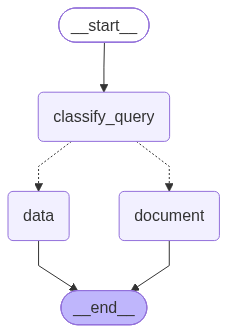

In [12]:
# 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [13]:
# 테스트
test_queries = [
    "LangGraph란 무엇인가요?",
    "RAG 시스템의 장점을 설명해주세요.",
    "이번 달 총 매출이 얼마인가요?",
    "부서별 직원 수를 알려주세요."
]

for query in test_queries:
    print("\n" + "="*70)
    print(f"질문: {query}")
    print("="*70)

    result = graph.invoke({
        "messages": [HumanMessage(content=query)],
        "query_type": ""
    })

    print(f"\n조회 유형: {result['query_type']}")
    print("\n응답:")
    print(result['messages'][-1].content)


질문: LangGraph란 무엇인가요?
조회 유형 분석 중...
조회 유형: document
이유: LangGraph가 무엇인지 개념 설명을 요청하는 질문으로, 특정 데이터 조회가 아니라 일반적인 정보/설명에 해당합니다.
문서 검색 중...

조회 유형: document

응답:
LangGraph는 **상태(state)를 유지하면서 여러 단계의 작업 흐름을 그래프 형태로 구성하는 프레임워크**입니다.  
주로 **LLM(대규모 언어 모델) 기반 애플리케이션**에서 복잡한 대화, 도구 호출, 분기 처리, 반복 실행, 인간 개입(Human-in-the-loop) 같은 흐름을 만들 때 사용합니다.

### 핵심 개념
- **노드(Node)**: 작업 단위입니다. 예를 들어 “질문 분류”, “검색 수행”, “답변 생성” 같은 단계입니다.
- **엣지(Edge)**: 노드 간 이동 경로입니다. 다음에 어떤 노드로 갈지 정의합니다.
- **상태(State)**: 그래프 전체가 공유하는 데이터입니다. 대화 기록, 검색 결과, 중간 판단값 등을 포함할 수 있습니다.
- **조건부 흐름**: 입력이나 중간 결과에 따라 다음 노드를 다르게 선택할 수 있습니다.
- **반복/루프**: 결과가 만족스럽지 않으면 다시 검색하거나 재생성하는 흐름도 만들 수 있습니다.

### 왜 쓰나요?
일반적인 순차형 체인(chain)보다 다음과 같은 상황에 강합니다.
- 대화가 **분기**되어야 할 때
- 여러 도구를 **상황에 따라 선택**해야 할 때
- 중간 결과를 보고 **재시도**해야 할 때
- 사람이 중간에 **검토/승인**해야 할 때
- 복잡한 에이전트 워크플로를 **명확하게 관리**하고 싶을 때

### 간단한 예
예를 들어 사용자 질문이 들어오면:
1. 질문이 단순한지 분류
2. 단순하면 바로 답변
3. 복잡하면 검색 도구 호출
4. 검색 결과를 바탕으로 답변 생성
5. 결과가 부족하면 다시 검색 또는 수정

이런 흐름을 LangGraph로 그래프처럼 구성할 수 있습니다.

###

---

### 참고 자료

- [LangGraph 조건부 엣지](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)
- [LangChain Structured Output](https://python.langchain.com/docs/how_to/structured_output/)
- [Pydantic BaseModel](https://docs.pydantic.dev/latest/concepts/models/)